# Prompt U-Net Version 332_h — Final Model trained only on head

## Summary

**V332 is the final benchmark-selected model**, combining the best individual choices from prior ablations. This time only on head mri data and 3000 epochs for faster training

| Component | Choice | Source |
|-----------|--------|--------|
| Architecture | `prompt_unet_313.py` (Float32 + SE Attention) | v316 / v313 |
| Offset | 16 | v316 |
| Loss | `binary_crossentropy` (plain BCE) | v316 — beats DiceBCE in benchmarks |
| Training buffer | 10,000 data points | v330 / v331 |
| Refresh cadence | every 30 epochs (slightly less aggressive than v330/v331's 20) | new |
| Datasets | **NAKO (Brain only)** | / |
| Total patients | 208 | v319 |
| Epochs | **3000** | / |

All hyper-parameters are read from the **Hyperparameters** cell below — edit there only.

> This notebook can also be run headless via `train_332.py` in the same directory.

## Setup

In [1]:
import os
import sys
import gc
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import mlflow
import tensorflow as tf

import logging
tf.get_logger().setLevel(logging.ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

print(f"TF  : {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1778050158.266043      97 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778050158.313330      97 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778050168.277555      97 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF  : 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Imports

In [2]:
# Allow importing from project root
notebook_dir = Path().resolve()
project_root  = notebook_dir.parent
sys.path.insert(0, str(project_root))

from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator  import DataGenerator

from utils.augmentations  import PromptUNetAugmenter
from utils.metrics        import dice_score_tf
from utils.visualization  import plot_result

from training.prompt_unet_313 import PromptUNet   # v313 architecture (Float32 + SE Attention)
from training.optimizer       import PromptUNetOptimizer

## Data Loading

208 patients total (v316 base + TopCoW from v319).

In [3]:
dataset_paths = [
    "data/train_data/nako_head.npz",       # 61 PIDs
]

dataloader    = DataLoader_npz(dataset_paths, val_size=0.01)
datagenerator = DataGenerator(dataloader)

print(f"Image size: {datagenerator.height} x {datagenerator.width}")


Loading NPZ dataset(s)…
Loaded 57 PIDs from /home/dpxuser/prompt-unet/data/train_data/nako_head.npz

Final dataset size: 57 patients.

Image size: 128 x 128


## Hyperparameters

In [4]:
version           = "p_unet_332_h"

epochs            = 3000
batch_size        = 128
dp_training       = 10000  # 10 k points per buffer refresh (from v330)
dp_testing        = 1000

offset            = 16     # slice-distance offset (from v316)
max_number_labels = 4

new_ds       = 30    # refresh training data every N epochs (slightly less aggressive than v330/v331's 20)
new_val_loop = 300   # run validation every N epochs

# LR schedule phases
warmup_epochs = 50
flat_epochs   = 1500

## Model & Optimizer

`WarmupFlatCosineDecay` schedule (from `optimizer.py`):
- Phase 1 (50 ep): linear warmup 1e-6 → 1e-3  
- Phase 2 (1500 ep): flat plateau at 1e-3  
- Phase 3 (2450 ep): cosine decay 1e-3 → 1e-5

Loss: **plain `binary_crossentropy`** — reverted from DiceBCE (v316 outperforms v330/v331 in benchmarks).

In [5]:
# ── Build model ────────────────────────────────────────────────────────────
model = PromptUNet(height=datagenerator.height, width=datagenerator.width)
# Loss stays as default binary_crossentropy (set inside PromptUNet.__init__)

# Warm-up forward pass to fully initialise all layers
_dummy_x = tf.random.uniform([1, datagenerator.height, datagenerator.width, 1])
_dummy_p = tf.random.uniform([1, datagenerator.height, datagenerator.width, 2])
_ = model.this([_dummy_x, _dummy_p])

print(f"Trainable params: {model.this.count_params():,}")

# ── Build optimizer (imported from optimizer.py) ───────────────────────────
opt_builder = PromptUNetOptimizer(
    epochs        = epochs,
    batch_size    = batch_size,
    dp_training   = dp_training,
    warmup_epochs = warmup_epochs,
    flat_epochs   = flat_epochs,
)
model.optimizer   = opt_builder.get_optimizer()
steps_per_epoch   = opt_builder.steps_per_epoch

I0000 00:00:1778050358.639323      97 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46569 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:ab:00.0, compute capability: 8.9
I0000 00:00:1778050360.283658      97 cuda_dnn.cc:461] Loaded cuDNN version 90500


Trainable params: 28,037,637


## Augmentation Pipeline

Same probabilities as v313–v316.

In [6]:
augmenter = PromptUNetAugmenter(
    prob_photo             = 0.45,
    prob_gamma             = 0.35,
    prob_noise             = 0.40,
    prob_independent_noise = 0.50,
    prob_geometric         = 0.50,
    prob_morph             = 0.30,
    prob_dropout           = 0.40,
    prob_false_pos         = 0.60,
    gamma_range                 = (0.85, 1.25),
    noise_std_range             = (0.0, 0.10),
    independent_noise_std_range = (0.0, 0.01),
)

## Persistent tf.data Pipeline

The pipeline graph (including `.map(augmenter)`) is built **once** here.  
When fresh training data is needed, only the numpy buffer is swapped — no TF graph nodes accumulate over time.

In [7]:
# ── Shared numpy buffer ────────────────────────────────────────────────────
_buf = {"x": None, "y": None, "p": None, "m": None}

def refresh_train_data():
    """Pull fresh random training data into the numpy buffer."""
    x_np, y_np, p_np, m_np, _ = datagenerator.get_data_points_numpy(
        max_data_points   = dp_training,
        offset            = offset,
        max_number_labels = max_number_labels,
    )
    _buf["x"] = x_np
    _buf["y"] = y_np
    _buf["p"] = p_np
    _buf["m"] = m_np
    gc.collect()


def _data_gen():
    """Yields one shuffled sample at a time from the numpy buffer."""
    n       = len(_buf["x"])
    indices = np.random.permutation(n)
    for i in indices:
        yield _buf["x"][i], _buf["y"][i], _buf["p"][i], _buf["m"][i]


H, W = datagenerator.height, datagenerator.width

# Build the pipeline graph ONCE for the entire training run
train_ds = (
    tf.data.Dataset.from_generator(
        _data_gen,
        output_signature=(
            tf.TensorSpec(shape=(H, W, 1), dtype=tf.float32),  # image
            tf.TensorSpec(shape=(H, W, 1), dtype=tf.float32),  # label
            tf.TensorSpec(shape=(H, W, 2), dtype=tf.float32),  # prompt
            tf.TensorSpec(shape=(),        dtype=tf.float32),  # modality
        )
    )
    .map(augmenter, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print("Pipeline ready.")

Pipeline ready.


## Training

/software/anaconda3/envs/machauer/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/06 08:52:52 INFO mlflow.tracking.fluent: Experiment with name 'p_unet_332_h' does not exist. Creating a new experiment.


Creating new Data Points ...
It took 3 seconds
Creating new Data Points ...
It took 33 seconds


I0000 00:00:1778050413.199605      97 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
E0000 00:00:1778050425.892432      97 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch    1  loss: 0.643395
Epoch    2  loss: 0.365109
Epoch    3  loss: 0.268650
Epoch    4  loss: 0.234765
Epoch    5  loss: 0.213164
Epoch    6  loss: 0.199094
Epoch    7  loss: 0.182519
Epoch    8  loss: 0.168439
Epoch    9  loss: 0.159397
Epoch   10  loss: 0.147163
Epoch   11  loss: 0.136376
Epoch   12  loss: 0.128932
Epoch   13  loss: 0.119567
Epoch   14  loss: 0.113068
Epoch   15  loss: 0.108441
Epoch   16  loss: 0.104307
Epoch   17  loss: 0.100150
Epoch   18  loss: 0.097397
Epoch   19  loss: 0.094136
Epoch   20  loss: 0.091404
Epoch   21  loss: 0.088857
Epoch   22  loss: 0.086853
Epoch   23  loss: 0.085076
Epoch   24  loss: 0.083686
Epoch   25  loss: 0.082093
Epoch   26  loss: 0.080189
Epoch   27  loss: 0.079028
Epoch   28  loss: 0.077709
Epoch   29  loss: 0.077423
Epoch   30  loss: 0.076596


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3275828..2.3436902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.325246..2.4465616].


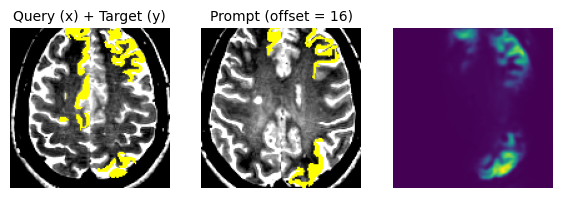

Creating new Data Points ...
It took 36 seconds
Epoch   31  loss: 0.074628
Epoch   32  loss: 0.073792
Epoch   33  loss: 0.073043
Epoch   34  loss: 0.072763
Epoch   35  loss: 0.072061
Epoch   36  loss: 0.071647
Epoch   37  loss: 0.071872
Epoch   38  loss: 0.070542
Epoch   39  loss: 0.070373
Epoch   40  loss: 0.070761
Epoch   41  loss: 0.070324
Epoch   42  loss: 0.069529
Epoch   43  loss: 0.068813
Epoch   44  loss: 0.068445
Epoch   45  loss: 0.068363
Epoch   46  loss: 0.068246
Epoch   47  loss: 0.068341
Epoch   48  loss: 0.068826
Epoch   49  loss: 0.068133
Epoch   50  loss: 0.067549
Epoch   51  loss: 0.066674
Epoch   52  loss: 0.067034
Epoch   53  loss: 0.066382
Epoch   54  loss: 0.066163
Epoch   55  loss: 0.065115
Epoch   56  loss: 0.065108
Epoch   57  loss: 0.065128
Epoch   58  loss: 0.064987
Epoch   59  loss: 0.065017


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3275828..2.3436902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.325246..2.4465616].


Epoch   60  loss: 0.063996


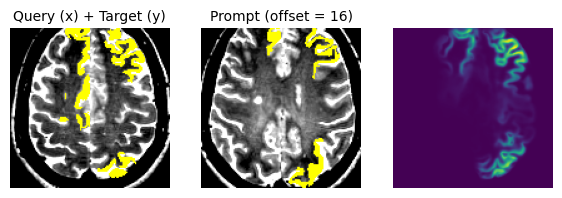

Creating new Data Points ...
It took 32 seconds
Epoch   61  loss: 0.064693
Epoch   62  loss: 0.063800
Epoch   63  loss: 0.063589
Epoch   64  loss: 0.063291
Epoch   65  loss: 0.062353
Epoch   66  loss: 0.061879
Epoch   67  loss: 0.061892
Epoch   68  loss: 0.061640
Epoch   69  loss: 0.061110
Epoch   70  loss: 0.060953
Epoch   71  loss: 0.060478
Epoch   72  loss: 0.060510
Epoch   73  loss: 0.060339
Epoch   74  loss: 0.059237
Epoch   75  loss: 0.059198
Epoch   76  loss: 0.058951
Epoch   77  loss: 0.058910
Epoch   78  loss: 0.058436
Epoch   79  loss: 0.058555
Epoch   80  loss: 0.058116
Epoch   81  loss: 0.057486
Epoch   82  loss: 0.057598
Epoch   83  loss: 0.056744
Epoch   84  loss: 0.056813
Epoch   85  loss: 0.056822
Epoch   86  loss: 0.057122
Epoch   87  loss: 0.055805
Epoch   88  loss: 0.055529
Epoch   89  loss: 0.055910
Epoch   90  loss: 0.055096


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3275828..2.3436902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.325246..2.4465616].


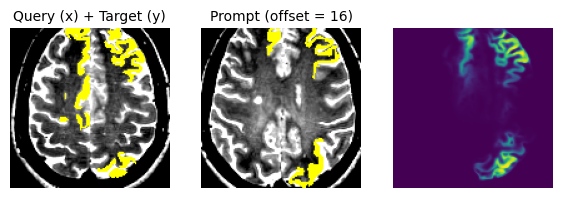

Creating new Data Points ...
It took 33 seconds
Epoch   91  loss: 0.060133
Epoch   92  loss: 0.058973
Epoch   93  loss: 0.058508
Epoch   94  loss: 0.057677
Epoch   95  loss: 0.057293
Epoch   96  loss: 0.057046
Epoch   97  loss: 0.056472
Epoch   98  loss: 0.056457
Epoch   99  loss: 0.055622
Epoch  100  loss: 0.055454
Epoch  101  loss: 0.055480
Epoch  102  loss: 0.054772
Epoch  103  loss: 0.054719
Epoch  104  loss: 0.054224
Epoch  105  loss: 0.053779
Epoch  106  loss: 0.054523
Epoch  107  loss: 0.053215
Epoch  108  loss: 0.053484
Epoch  109  loss: 0.053281
Epoch  110  loss: 0.053055
Epoch  111  loss: 0.052114
Epoch  112  loss: 0.052293
Epoch  113  loss: 0.052598
Epoch  114  loss: 0.051936
Epoch  115  loss: 0.051717
Epoch  116  loss: 0.051375
Epoch  117  loss: 0.051014
Epoch  118  loss: 0.051012
Epoch  119  loss: 0.050668
Epoch  120  loss: 0.050406


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3275828..2.3436902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.325246..2.4465616].


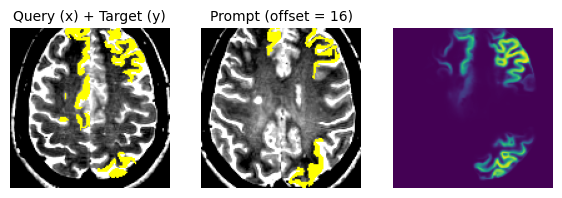

Creating new Data Points ...
It took 34 seconds
Epoch  121  loss: 0.057217
Epoch  122  loss: 0.056280
Epoch  123  loss: 0.055094
Epoch  124  loss: 0.054557
Epoch  125  loss: 0.054221
Epoch  126  loss: 0.053585
Epoch  127  loss: 0.053234
Epoch  128  loss: 0.052351
Epoch  129  loss: 0.052504
Epoch  130  loss: 0.051814
Epoch  131  loss: 0.052406
Epoch  132  loss: 0.051179
Epoch  133  loss: 0.051105
Epoch  134  loss: 0.051563
Epoch  135  loss: 0.050497
Epoch  136  loss: 0.050858
Epoch  137  loss: 0.050289
Epoch  138  loss: 0.050691
Epoch  139  loss: 0.049801
Epoch  140  loss: 0.049219
Epoch  141  loss: 0.049377
Epoch  142  loss: 0.049126
Epoch  143  loss: 0.048754
Epoch  144  loss: 0.048431
Epoch  145  loss: 0.048641
Epoch  146  loss: 0.048533
Epoch  147  loss: 0.048369
Epoch  148  loss: 0.048043
Epoch  149  loss: 0.048156
Epoch  150  loss: 0.047260


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3275828..2.3436902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.325246..2.4465616].


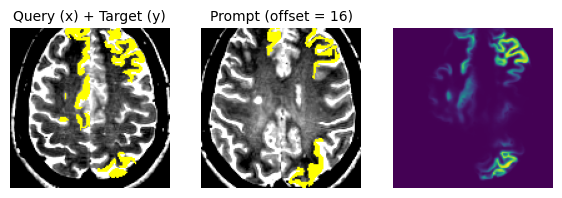

Creating new Data Points ...
It took 38 seconds
Epoch  151  loss: 0.058532
Epoch  152  loss: 0.056359
Epoch  153  loss: 0.055605
Epoch  154  loss: 0.054524
Epoch  155  loss: 0.053906
Epoch  156  loss: 0.053782
Epoch  157  loss: 0.052940
Epoch  158  loss: 0.052838
Epoch  159  loss: 0.052875
Epoch  160  loss: 0.052455
Epoch  161  loss: 0.051903
Epoch  162  loss: 0.051969
Epoch  163  loss: 0.051893
Epoch  164  loss: 0.050724
Epoch  165  loss: 0.051138
Epoch  166  loss: 0.050809
Epoch  167  loss: 0.050313
Epoch  168  loss: 0.050069
Epoch  169  loss: 0.049854
Epoch  170  loss: 0.050056
Epoch  171  loss: 0.049655
Epoch  172  loss: 0.049496
Epoch  173  loss: 0.049324
Epoch  174  loss: 0.049160
Epoch  175  loss: 0.049663
Epoch  176  loss: 0.049490
Epoch  177  loss: 0.048279
Epoch  178  loss: 0.048577
Epoch  179  loss: 0.048883
Epoch  180  loss: 0.048433


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3275828..2.3436902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.325246..2.4465616].


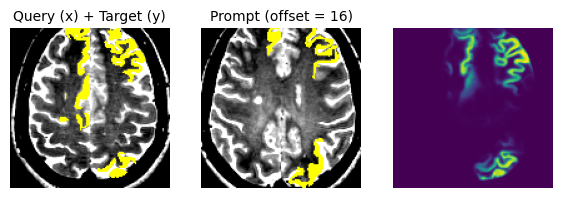

Creating new Data Points ...
It took 34 seconds
Epoch  181  loss: 0.054323
Epoch  182  loss: 0.052176
Epoch  183  loss: 0.051300
Epoch  184  loss: 0.050463
Epoch  185  loss: 0.050045
Epoch  186  loss: 0.050058
Epoch  187  loss: 0.049316
Epoch  188  loss: 0.048639
Epoch  189  loss: 0.048551
Epoch  190  loss: 0.048058
Epoch  191  loss: 0.047620
Epoch  192  loss: 0.047657
Epoch  193  loss: 0.047378
Epoch  194  loss: 0.047076
Epoch  195  loss: 0.046560
Epoch  196  loss: 0.046806
Epoch  197  loss: 0.047084
Epoch  198  loss: 0.046739
Epoch  199  loss: 0.046417
Epoch  200  loss: 0.045882
Epoch  201  loss: 0.045640
Epoch  202  loss: 0.045589
Epoch  203  loss: 0.045067
Epoch  204  loss: 0.045399
Epoch  205  loss: 0.045383
Epoch  206  loss: 0.044816
Epoch  207  loss: 0.045197
Epoch  208  loss: 0.044970
Epoch  209  loss: 0.044545
Epoch  210  loss: 0.045026


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3275828..2.3436902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.325246..2.4465616].


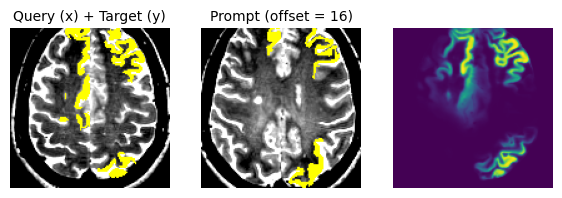

Creating new Data Points ...
It took 32 seconds
Epoch  211  loss: 0.055557
Epoch  212  loss: 0.053367
Epoch  213  loss: 0.053105
Epoch  214  loss: 0.052528
Epoch  215  loss: 0.051535
Epoch  216  loss: 0.050436
Epoch  217  loss: 0.050837
Epoch  218  loss: 0.050044
Epoch  219  loss: 0.049634
Epoch  220  loss: 0.050144
Epoch  221  loss: 0.049027
Epoch  222  loss: 0.049181
Epoch  223  loss: 0.049600
Epoch  224  loss: 0.049613
Epoch  225  loss: 0.048647
Epoch  226  loss: 0.047973
Epoch  227  loss: 0.048194
Epoch  228  loss: 0.048117
Epoch  229  loss: 0.047308
Epoch  230  loss: 0.047564
Epoch  231  loss: 0.047488
Epoch  232  loss: 0.047344
Epoch  233  loss: 0.047203
Epoch  234  loss: 0.046450
Epoch  235  loss: 0.046058
Epoch  236  loss: 0.046786
Epoch  237  loss: 0.046358
Epoch  238  loss: 0.046391
Epoch  239  loss: 0.046780
Epoch  240  loss: 0.046565


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3275828..2.3436902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.325246..2.4465616].


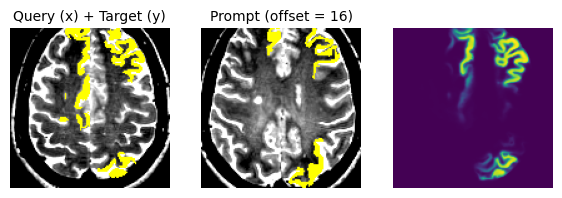

Creating new Data Points ...
It took 29 seconds
Epoch  241  loss: 0.053503
Epoch  242  loss: 0.051399
Epoch  243  loss: 0.050241
Epoch  244  loss: 0.050391
Epoch  245  loss: 0.049059
Epoch  246  loss: 0.049018
Epoch  247  loss: 0.048184
Epoch  248  loss: 0.048359
Epoch  249  loss: 0.047353
Epoch  250  loss: 0.047591
Epoch  251  loss: 0.046962
Epoch  252  loss: 0.047245
Epoch  253  loss: 0.046715
Epoch  254  loss: 0.046024
Epoch  255  loss: 0.045966
Epoch  256  loss: 0.046359
Epoch  257  loss: 0.046258
Epoch  258  loss: 0.045731
Epoch  259  loss: 0.045501
Epoch  260  loss: 0.045771
Epoch  261  loss: 0.045070
Epoch  262  loss: 0.044950
Epoch  263  loss: 0.044492
Epoch  264  loss: 0.044816
Epoch  265  loss: 0.044161
Epoch  266  loss: 0.044827
Epoch  267  loss: 0.044092
Epoch  268  loss: 0.044058
Epoch  269  loss: 0.044147
Epoch  270  loss: 0.044185


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3275828..2.3436902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.325246..2.4465616].


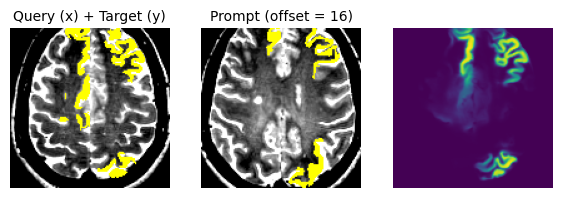

Creating new Data Points ...
It took 31 seconds
Epoch  271  loss: 0.051491
Epoch  272  loss: 0.050132
Epoch  273  loss: 0.048909
Epoch  274  loss: 0.048005
Epoch  275  loss: 0.048031
Epoch  276  loss: 0.047665
Epoch  277  loss: 0.046990
Epoch  278  loss: 0.046436
Epoch  279  loss: 0.046362
Epoch  280  loss: 0.045851
Epoch  281  loss: 0.045809
Epoch  282  loss: 0.045395
Epoch  283  loss: 0.045142
Epoch  284  loss: 0.044478
Epoch  285  loss: 0.044528
Epoch  286  loss: 0.044524
Epoch  287  loss: 0.044544
Epoch  288  loss: 0.044143
Epoch  289  loss: 0.044300
Epoch  290  loss: 0.044149
Epoch  291  loss: 0.043873
Epoch  292  loss: 0.043664
Epoch  293  loss: 0.043334
Epoch  294  loss: 0.043251
Epoch  295  loss: 0.043237
Epoch  296  loss: 0.043053
Epoch  297  loss: 0.042949
Epoch  298  loss: 0.042595
Epoch  299  loss: 0.042980
Epoch  300  loss: 0.043127


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3275828..2.3436902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.325246..2.4465616].


  Validation loss: 0.4369


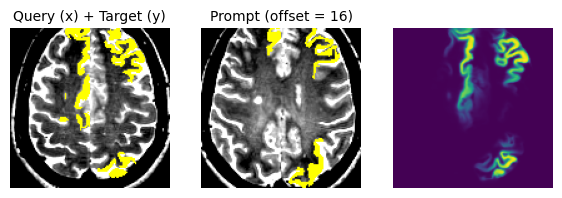

Creating new Data Points ...
It took 31 seconds
Epoch  301  loss: 0.049679
Epoch  302  loss: 0.047627
Epoch  303  loss: 0.047385
Epoch  304  loss: 0.046432
Epoch  305  loss: 0.045698
Epoch  306  loss: 0.044981
Epoch  307  loss: 0.044615
Epoch  308  loss: 0.044274
Epoch  309  loss: 0.043793
Epoch  310  loss: 0.043904
Epoch  311  loss: 0.044029
Epoch  312  loss: 0.044202
Epoch  313  loss: 0.043468
Epoch  314  loss: 0.043516
Epoch  315  loss: 0.042891
Epoch  316  loss: 0.042827
Epoch  317  loss: 0.042680
Epoch  318  loss: 0.042640
Epoch  319  loss: 0.042541
Epoch  320  loss: 0.042330
Epoch  321  loss: 0.041675
Epoch  322  loss: 0.041310
Epoch  323  loss: 0.041886
Epoch  324  loss: 0.041588
Epoch  325  loss: 0.041459
Epoch  326  loss: 0.040899
Epoch  327  loss: 0.041289
Epoch  328  loss: 0.041157
Epoch  329  loss: 0.041140


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3275828..2.3436902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.325246..2.4465616].


Epoch  330  loss: 0.040866


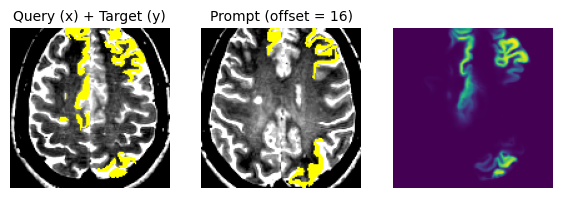

Creating new Data Points ...
It took 32 seconds
Epoch  331  loss: 0.051427
Epoch  332  loss: 0.049231
Epoch  333  loss: 0.048031
Epoch  334  loss: 0.047713
Epoch  335  loss: 0.046988
Epoch  336  loss: 0.046769
Epoch  337  loss: 0.046219
Epoch  338  loss: 0.045939
Epoch  339  loss: 0.045336
Epoch  340  loss: 0.045295
Epoch  341  loss: 0.044883
Epoch  342  loss: 0.044860
Epoch  343  loss: 0.044476
Epoch  344  loss: 0.044489
Epoch  345  loss: 0.043899
Epoch  346  loss: 0.044087
Epoch  347  loss: 0.043856
Epoch  348  loss: 0.043619
Epoch  349  loss: 0.043110
Epoch  350  loss: 0.043316
Epoch  351  loss: 0.043177
Epoch  352  loss: 0.042791
Epoch  353  loss: 0.042656
Epoch  354  loss: 0.042474
Epoch  355  loss: 0.042337
Epoch  356  loss: 0.042034
Epoch  357  loss: 0.042507
Epoch  358  loss: 0.042209
Epoch  359  loss: 0.041754
Epoch  360  loss: 0.042142


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3275828..2.3436902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.325246..2.4465616].


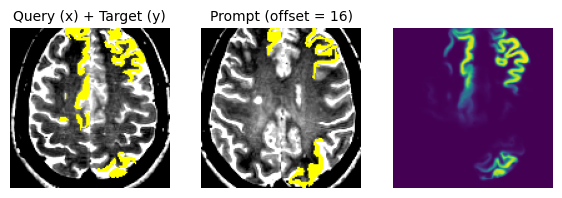

Creating new Data Points ...
It took 30 seconds
Epoch  361  loss: 0.051838
Epoch  362  loss: 0.048984
Epoch  363  loss: 0.048776
Epoch  364  loss: 0.047710
Epoch  365  loss: 0.046430
Epoch  366  loss: 0.046210
Epoch  367  loss: 0.046255
Epoch  368  loss: 0.045224
Epoch  369  loss: 0.045393
Epoch  370  loss: 0.045272
Epoch  371  loss: 0.044618
Epoch  372  loss: 0.044450
Epoch  373  loss: 0.043677
Epoch  374  loss: 0.043897
Epoch  375  loss: 0.043879
Epoch  376  loss: 0.043830
Epoch  377  loss: 0.042988
Epoch  378  loss: 0.043739
Epoch  379  loss: 0.043506
Epoch  380  loss: 0.042999
Epoch  381  loss: 0.042857
Epoch  382  loss: 0.043141
Epoch  383  loss: 0.043192
Epoch  384  loss: 0.042608
Epoch  385  loss: 0.042727
Epoch  386  loss: 0.042209
Epoch  387  loss: 0.042213
Epoch  388  loss: 0.042074
Epoch  389  loss: 0.042366


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3275828..2.3436902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.325246..2.4465616].


Epoch  390  loss: 0.042058


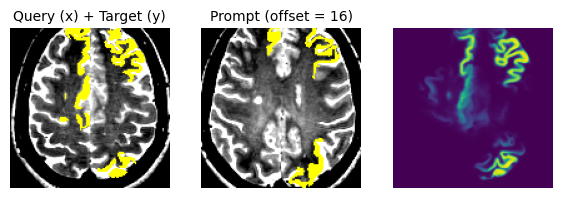

Creating new Data Points ...
It took 30 seconds
Epoch  391  loss: 0.048292
Epoch  392  loss: 0.046537
Epoch  393  loss: 0.046049
Epoch  394  loss: 0.045056
Epoch  395  loss: 0.044592
Epoch  396  loss: 0.044473
Epoch  397  loss: 0.043408
Epoch  398  loss: 0.043840
Epoch  399  loss: 0.043305
Epoch  400  loss: 0.043141
Epoch  401  loss: 0.042843
Epoch  402  loss: 0.043185
Epoch  403  loss: 0.043137
Epoch  404  loss: 0.041947
Epoch  405  loss: 0.042491
Epoch  406  loss: 0.042104
Epoch  407  loss: 0.041594
Epoch  408  loss: 0.041748
Epoch  409  loss: 0.041360
Epoch  410  loss: 0.041236
Epoch  411  loss: 0.040864
Epoch  412  loss: 0.040812
Epoch  413  loss: 0.040674
Epoch  414  loss: 0.040813
Epoch  415  loss: 0.040967
Epoch  416  loss: 0.041058
Epoch  417  loss: 0.040616
Epoch  418  loss: 0.040560
Epoch  419  loss: 0.039942
Epoch  420  loss: 0.040207


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3275828..2.3436902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.325246..2.4465616].


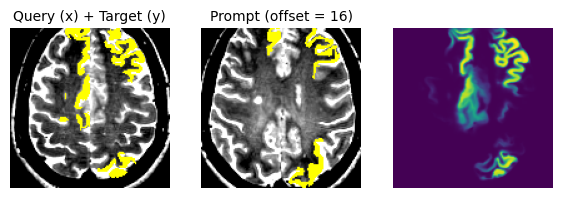

Creating new Data Points ...
It took 31 seconds
Epoch  421  loss: 0.048866
Epoch  422  loss: 0.046199
Epoch  423  loss: 0.046010
Epoch  424  loss: 0.044998
Epoch  425  loss: 0.044521
Epoch  426  loss: 0.044092
Epoch  427  loss: 0.043606
Epoch  428  loss: 0.043611
Epoch  429  loss: 0.043690
Epoch  430  loss: 0.043162
Epoch  431  loss: 0.042985
Epoch  432  loss: 0.042463
Epoch  433  loss: 0.042251
Epoch  434  loss: 0.042382
Epoch  435  loss: 0.041775
Epoch  436  loss: 0.041849
Epoch  437  loss: 0.042000
Epoch  438  loss: 0.042049
Epoch  439  loss: 0.040955
Epoch  440  loss: 0.041514
Epoch  441  loss: 0.040962
Epoch  442  loss: 0.040402
Epoch  443  loss: 0.041197
Epoch  444  loss: 0.040945
Epoch  445  loss: 0.040659
Epoch  446  loss: 0.040578
Epoch  447  loss: 0.040698
Epoch  448  loss: 0.040410
Epoch  449  loss: 0.040403
Epoch  450  loss: 0.039815


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3275828..2.3436902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.325246..2.4465616].


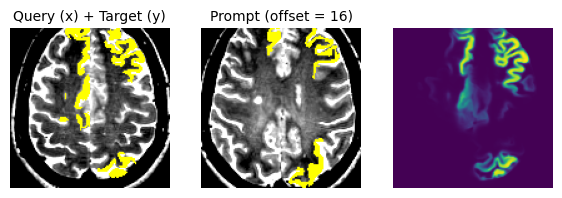

Creating new Data Points ...
It took 33 seconds
Epoch  451  loss: 0.049178
Epoch  452  loss: 0.047066
Epoch  453  loss: 0.046209
Epoch  454  loss: 0.045838
Epoch  455  loss: 0.045093
Epoch  456  loss: 0.044857
Epoch  457  loss: 0.044420
Epoch  458  loss: 0.043901
Epoch  459  loss: 0.043938
Epoch  460  loss: 0.043730
Epoch  461  loss: 0.043427
Epoch  462  loss: 0.043244
Epoch  463  loss: 0.042625
Epoch  464  loss: 0.042770
Epoch  465  loss: 0.042401
Epoch  466  loss: 0.042198
Epoch  467  loss: 0.041921
Epoch  468  loss: 0.042048
Epoch  469  loss: 0.041589
Epoch  470  loss: 0.041638
Epoch  471  loss: 0.041519
Epoch  472  loss: 0.041631
Epoch  473  loss: 0.041657
Epoch  474  loss: 0.041338
Epoch  475  loss: 0.041502
Epoch  476  loss: 0.041507
Epoch  477  loss: 0.040940
Epoch  478  loss: 0.040987
Epoch  479  loss: 0.041135
Epoch  480  loss: 0.040893


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3275828..2.3436902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.325246..2.4465616].


Epoch  493  loss: 0.040667
Epoch  494  loss: 0.040430
Epoch  495  loss: 0.040220
Epoch  496  loss: 0.040148
Epoch  497  loss: 0.040215
Epoch  498  loss: 0.039969
Epoch  499  loss: 0.039618
Epoch  500  loss: 0.039820
Epoch  501  loss: 0.039548
Epoch  502  loss: 0.039174
Epoch  503  loss: 0.039455
Epoch  504  loss: 0.039275
Epoch  505  loss: 0.038918
Epoch  506  loss: 0.038870
Epoch  507  loss: 0.039109
Epoch  508  loss: 0.038637
Epoch  509  loss: 0.038912
Epoch  510  loss: 0.038857


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3275828..2.3436902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.325246..2.4465616].


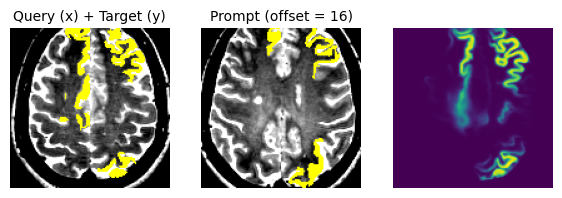

Creating new Data Points ...
It took 29 seconds
Epoch  511  loss: 0.048340
Epoch  512  loss: 0.046627
Epoch  513  loss: 0.046159
Epoch  514  loss: 0.045051
Epoch  515  loss: 0.044549
Epoch  516  loss: 0.043919
Epoch  517  loss: 0.043857
Epoch  518  loss: 0.043135
Epoch  519  loss: 0.043380
Epoch  520  loss: 0.043290


In [ ]:
def fit(epochs):
    mlflow.set_experiment(version)

    with mlflow.start_run():

        mlflow.log_params({
            "batch_size"        : batch_size,
            "max_number_labels" : max_number_labels,
            "num_epochs"        : epochs,
            "dp_training"       : dp_training,
            "offset"            : offset,
            "loss_function"     : "binary_crossentropy",
            "new_ds"            : new_ds,
            "warmup_epochs"     : warmup_epochs,
            "flat_epochs"       : flat_epochs,
            "prob_geometric"    : augmenter.prob_geometric,
            "prob_morph"        : augmenter.prob_morph,
            "gamma_range"       : str(augmenter.gamma_range),
            "trainable_params"  : model.this.count_params(),
            "scale_augmentation": "50% crop 128px / 50% crop [128,256]px resized",
            "leakage_fix"       : "crop origin from support label only",
            "se_attention"      : "enabled",
            "mixed_precision"   : "false",
            "datasets"          : "nako+total_seg+msd+brats_gli+brats_men_rt+TopCoW_MR+TopCoW_CT",
        })

        # ── Validation dataset (built once, no augmentation) ───────────────────
        val_x, val_y, val_p, val_m, _ = datagenerator.get_val_data_points_numpy(
            max_data_points   = dp_testing,
            offset            = offset,
            max_number_labels = max_number_labels,
        )
        test_ds = (
            tf.data.Dataset.from_tensor_slices((val_x, val_y, val_p, val_m))
            .batch(1)
        )

        # ── Prime the training buffer before the loop ──────────────────────────
        refresh_train_data()

        for epoch in range(epochs):

            model.train_loss.reset_state()

            # Log learning rate
            lr = model.optimizer.learning_rate
            if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
                lr = float(lr(epoch * steps_per_epoch))
            else:
                lr = float(lr.numpy())
            mlflow.log_metric("learning_rate", lr, step=epoch)

            # Checkpoint every 8 epochs
            if epoch % 8 == 0 and epoch != 0:
                model.this.save(f"{version}.keras")

            # Validation every new_val_loop epochs
            if epoch % new_val_loop == 0 and epoch != 0:
                total_dice = 0.0
                for z in test_ds:
                    pred = model.this([z[0], z[2]], training=False)
                    total_dice += float(dice_score_tf(z[1][..., 0:1], pred))
                val_loss = 1.0 - total_dice / dp_testing
                mlflow.log_metric("validation_loss", val_loss, step=epoch)
                print(f"  Validation loss: {val_loss:.4f}")

            # Refresh training data every new_ds epochs
            if epoch % new_ds == 0 and epoch != 0:
                # Visualise one validation prediction
                z_test = next(iter(test_ds))
                pred   = model.this([z_test[0], z_test[2]], training=False)
                plot_result(z_test[0][0], z_test[1][0], z_test[2][0], pred[0], offset, "")

                # Swap numpy buffer — pipeline graph stays intact
                refresh_train_data()

            # Train one epoch
            model.train_epoch(train_dataset=train_ds)

            epoch_loss = float(model.train_loss.result())
            print(f"Epoch {epoch + 1:>4d}  loss: {epoch_loss:.6f}")
            mlflow.log_metric("train_loss", epoch_loss, step=epoch)


fit(epochs)